In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from dotenv import load_dotenv

load_dotenv()

from sqlalchemy import create_engine
import os

def connect_to_db():
    engine = create_engine(
        f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@"
        f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
    )
    return engine

engine = connect_to_db()

conn = engine.connect()

In [3]:
df = pd.read_sql("SELECT * FROM public.gold_model_dataset", engine)

df.head()

,user_id,is_mobile,is_package,channel,cnt,trip_type,is_family_trip,is_multi_room,total_guests,stay_duration,...,avg_session_intensity,avg_stay_duration,avg_advance_booking_days,mobile_usage_rate,destination_booking_rate,destination_popularity,cluster_booking_rate,cluster_popularity,hotel_cluster,is_booking
0,14,0,0,9,1,solo,0,0,1,2,...,1.0,2.0,54.0,0.0,0.0697,3544,0.0341,264,88,0
1,38,0,0,2,1,group,0,0,2,4,...,1.0,4.0,123.0,0.0,0.1277,47,0.1001,1129,33,0
2,40,0,0,0,1,solo,0,0,1,1,...,1.0,1.0,1.0,0.0,0.1000,100,0.0655,885,76,0
3,156,0,0,5,1,family,1,0,4,1,...,1.0,1.0,14.0,0.0,0.1215,214,0.1317,896,13,0
4,156,0,0,5,1,family,1,0,4,1,...,1.0,1.0,14.0,0.0,0.1215,214,0.1143,1260,16,0


In [4]:
df.info()
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 99471 entries, 0 to 99470
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    99471 non-null  int64  
 1   is_mobile                  99471 non-null  int64  
 2   is_package                 99471 non-null  int64  
 3   channel                    99471 non-null  int64  
 4   cnt                        99471 non-null  int64  
 5   trip_type                  99471 non-null  str    
 6   is_family_trip             99471 non-null  int64  
 7   is_multi_room              99471 non-null  int64  
 8   total_guests               99471 non-null  int64  
 9   stay_duration              99471 non-null  int64  
 10  advance_booking_days       99471 non-null  int64  
 11  user_location_country      99471 non-null  int64  
 12  hotel_country              99471 non-null  int64  
 13  srch_destination_id        99471 non-null  int64  
 14  s

distance_clean               35884
is_mobile                        0
user_id                          0
channel                          0
cnt                              0
trip_type                        0
is_package                       0
is_multi_room                    0
total_guests                     0
stay_duration                    0
advance_booking_days             0
user_location_country            0
hotel_country                    0
srch_destination_id              0
is_family_trip                   0
srch_destination_type_id         0
orig_destination_distance        0
distance_group                   0
is_distance_unknown              0
distance_behavior_group          0
user_booking_rate                0
avg_session_intensity            0
avg_stay_duration                0
avg_advance_booking_days         0
mobile_usage_rate                0
destination_booking_rate         0
destination_popularity           0
cluster_booking_rate             0
cluster_popularity  

In [5]:
df[df["stay_duration"] <= 0].shape
df[df["advance_booking_days"] < 0].shape
df[df["total_guests"] <= 0].shape

(173, 31)

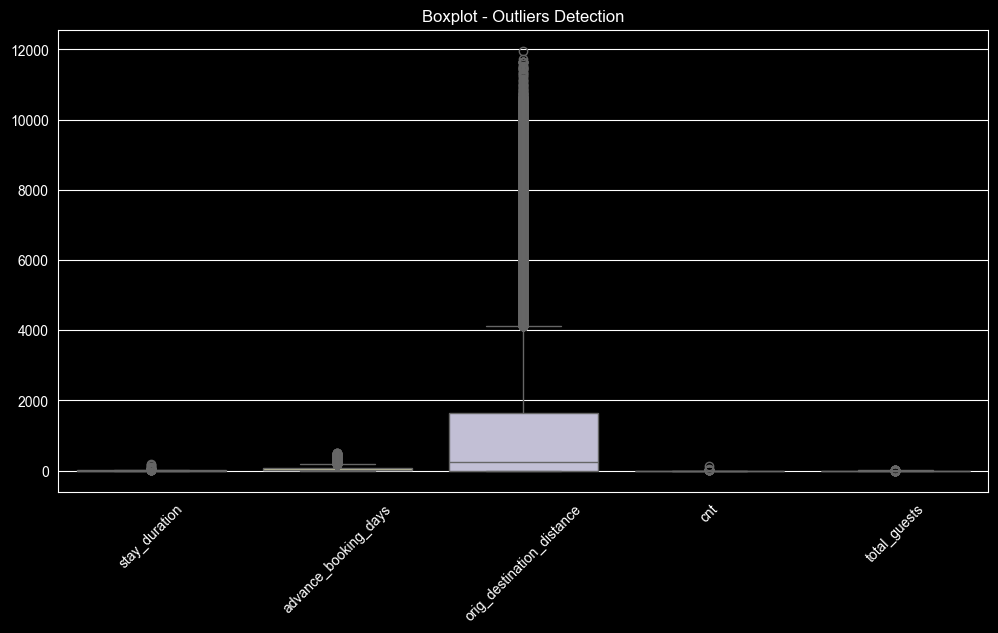

In [6]:
num_cols = [
    "stay_duration",
    "advance_booking_days",
    "orig_destination_distance",
    "cnt",
    "total_guests"
]

plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.title("Boxplot - Outliers Detection")
plt.xticks(rotation=45)
plt.show()

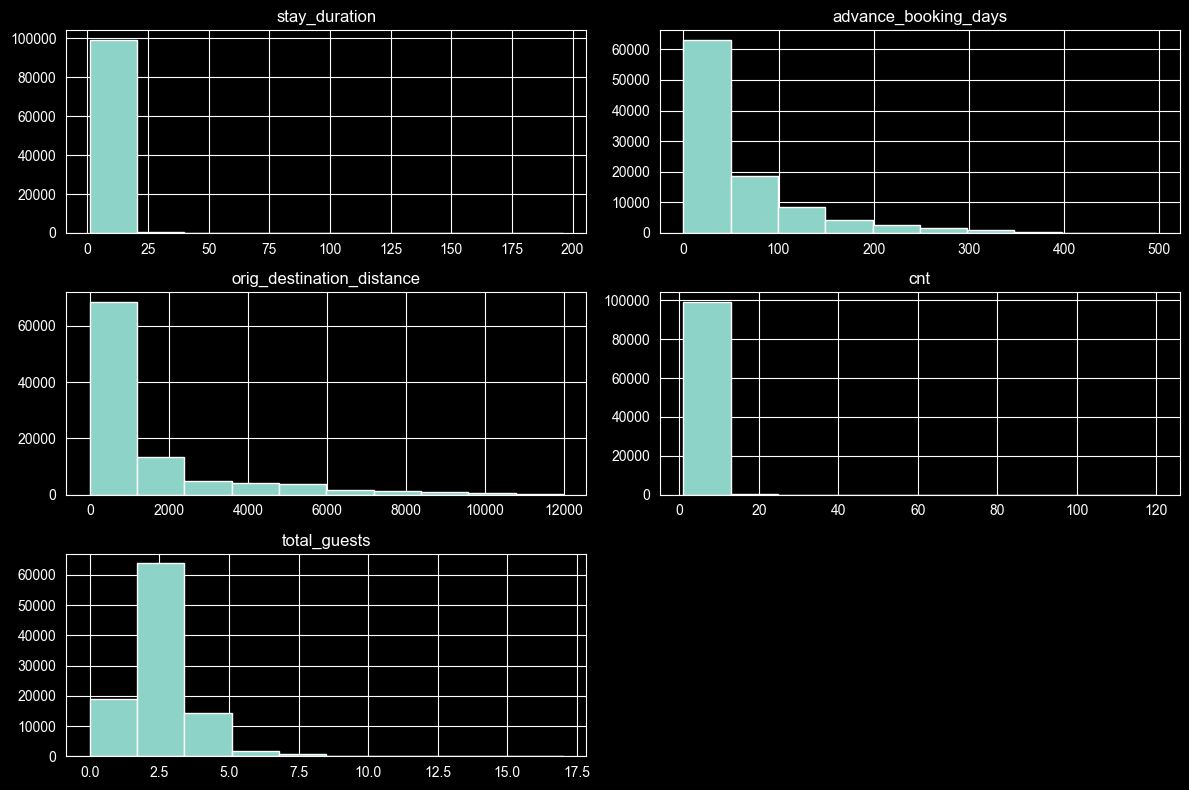

In [7]:
df[num_cols].hist(figsize=(12,8))
plt.tight_layout()

In [8]:
for col in num_cols:
    p1, p99 = np.percentile(df[col], [1, 99])
    print(f"{col} → P1: {p1:.2f}, P99: {p99:.2f}")

stay_duration → P1: 1.00, P99: 14.00
advance_booking_days → P1: 0.00, P99: 300.00
orig_destination_distance → P1: -1.00, P99: 8909.98
cnt → P1: 1.00, P99: 7.00
total_guests → P1: 1.00, P99: 6.00


In [9]:
df_outliers = df[
    (df["stay_duration"] > 30) |
    (df["advance_booking_days"] > 365) |
    (df["orig_destination_distance"] > 10000)
]

df_outliers.head()

,user_id,is_mobile,is_package,channel,cnt,trip_type,is_family_trip,is_multi_room,total_guests,stay_duration,...,avg_session_intensity,avg_stay_duration,avg_advance_booking_days,mobile_usage_rate,destination_booking_rate,destination_popularity,cluster_booking_rate,cluster_popularity,hotel_cluster,is_booking
140,1899,0,0,5,1,group,0,0,2,3,...,1.0,3.0,202.0,0.0,0.0968,93,0.0734,1145,40,0
340,3775,0,0,3,1,group,0,0,2,3,...,1.0,3.0,21.0,0.0,0.0000,1,0.1156,1376,82,0
416,4497,0,0,9,1,group,0,0,2,3,...,1.0,3.0,106.0,0.0,0.0000,2,0.0549,1311,30,0
644,6940,0,0,0,1,group,0,1,4,3,...,1.0,3.0,50.0,0.0,0.0000,16,0.0487,760,63,0
945,10683,0,0,5,1,group,0,0,2,4,...,1.0,4.0,21.0,0.0,0.0498,1305,0.0789,1343,37,0


In [10]:
df.duplicated().sum()

np.int64(15)

In [11]:
df[df["srch_destination_id"].isnull()].shape
df[df["hotel_cluster"].isnull()].shape

(0, 31)

In [12]:
df["long_stay"] = df["stay_duration"] > df["stay_duration"].quantile(0.95)

df.groupby("long_stay")["is_booking"].mean()

long_stay
False    0.082580
True     0.028709
Name: is_booking, dtype: float64

In [13]:
(df["orig_destination_distance"] == -1).sum()

np.int64(35884)

In [14]:
conn.close()